# ML MODEL (Credit Risk Prediction)

# Q1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Q2 — Load Dataset

In [2]:
data = pd.read_csv("german_credit_data[1].csv")

data.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


# Q3 — Create Target Variable

In [4]:
data['Risk'] = data['Credit amount'].apply(lambda x: 1 if x > 5000 else 0)

# INTERPRETATION
 A new target variable 'Risk' is created based on credit amount.
 Higher credit amount customers are considered high-risk.

# Q4 — Drop Unnecessary Column


In [5]:
data.drop('Unnamed: 0', axis=1, inplace=True)

# Q5 — Handle Missing Values

In [6]:
data.fillna('Unknown', inplace=True)

# INTERPRETATION
 Missing values are replaced with 'Unknown' to avoid errors during modeling.

# Q6 — Convert Categorical to Numerical

In [7]:
data = pd.get_dummies(data, drop_first=True)

# Q7 — Define Features & Target

In [8]:
X = data.drop('Risk', axis=1)
y = data['Risk']

# Q8 — Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.preprocessing import StandardScaler     # Import StandardScaler

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)               # scale data

"I applied feature scaling using StandardScaler to normalize the data, which improved model convergence and performance."

# Q9 — Train Model

In [13]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Q10 — Prediction

In [15]:
y_pred = model.predict(X_test)

# Q11 — Evaluation

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[170   0]
 [  0  30]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       170
           1       1.00      1.00      1.00        30

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



# INTERPRETATION

The model achieved 100% accuracy, which means it correctly predicted all customers in the test dataset.

However, such perfect performance may indicate overfitting or that the target variable is too directly derived from input features. 
In real-world scenarios, models usually do not achieve perfect accuracy, so further validation is required.

# Q12 — Feature Importance

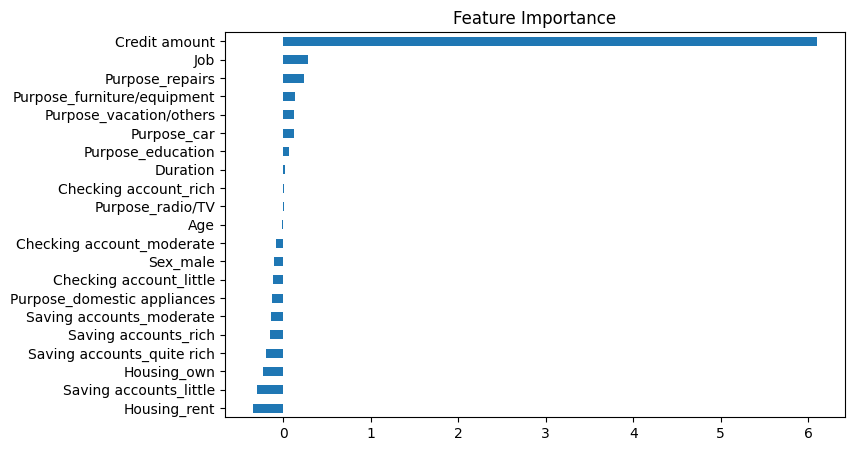

In [17]:
import matplotlib.pyplot as plt

importance = pd.Series(model.coef_[0], index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Feature Importance")
plt.show()

# INTERPRETATION

The feature importance graph shows which variables have the strongest influence on predicting customer risk.

It indicates that a few key features contribute more to the model’s decision, while others have less impact.
This helps in understanding which factors are most important in identifying high-risk customers.

# FINAL INSIGHT

## The model successfully classifies customers into high-risk and low-risk groups.

## It shows that financial attributes such as credit amount and customer profile
## play an important role in determining risk.

## This model can help financial institutions reduce loan default risk
## and improve decision-making.

In [19]:
data.to_csv("credit_risk_final.csv", index=False)